## Create a Basin Figure with Sites

In [2]:
# Import necessary packages 
import geopandas as gpd
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Change to your file path where you have ice boundaries stored
gdf = gpd.read_file("Basins_Antarctica_v02.shp")

print(gdf.columns)

Index(['NAME', 'Regions', 'Subregions', 'TYPE', 'Asso_Shelf', 'geometry'], dtype='object')


In [3]:
# Each individual basin has a unique identifier in 'NAME', you can list them out here. 
# This is important because when you call them later, you need to spell them exactly as they are listed.

name = gdf['NAME'].unique()
print(name)

['LarsenE' 'Academy' 'Brunt_Stancomb' 'Riiser-Larsen' 'Ekstrom' 'Atka'
 'Princess_Martha_Coast1' 'Quar' 'Princess_Martha_Coast2' 'Jelbart'
 'Jutulstraumen' 'Princess_Astrid_Coast1' 'Nivl' 'Vigrid'
 'Princess_Astrid_Coast2' 'Borchgrevink' 'Lazarev' 'Baudouin'
 'Prince_Harald_Coast1' 'Prince_Harald_Coast2' 'Prince_Harald'
 'Shirase_Glacier' 'Prince_Olav_Coast' 'Rayner_Thyer' 'Enderby_Land'
 'MacRobertson_Land' 'Publications' 'WilmaRobertDowner' 'Mawson_Coast'
 'Ingrid_Christensen_Coast' 'Leopold_and_Astrid_Coast' 'Wilhelm_II_Coast'
 'Denman_Scott' 'Tracy_Tremenchus' 'Budd_Coast' 'Knox_Coast'
 'Conger_Glenzer' 'Vincennes_Bay' 'Law_Dome' 'Totten' 'Moscow'
 'Sabrina_Coast2' 'Sabrina_Coast1' 'Voyeykov' 'Holmes' 'Frost'
 'Clarie_Coast' 'Dibble' 'Adelie_Coast' 'Mertz' 'Wilkes_Land1' 'Ninnis'
 'Wilkes_Land2' 'Cook' 'Slava' 'David' 'Dry Valleys' 'Mercer'
 'Shirases_Coast1' 'Ruppert_Coast2' 'Land' 'Smith' 'Pine_Island'
 'Thwaites' 'Cosgrove' 'King' 'Cooke' 'Fox' 'Ferrigno' 'Rydberg_Peninsula'
 'W

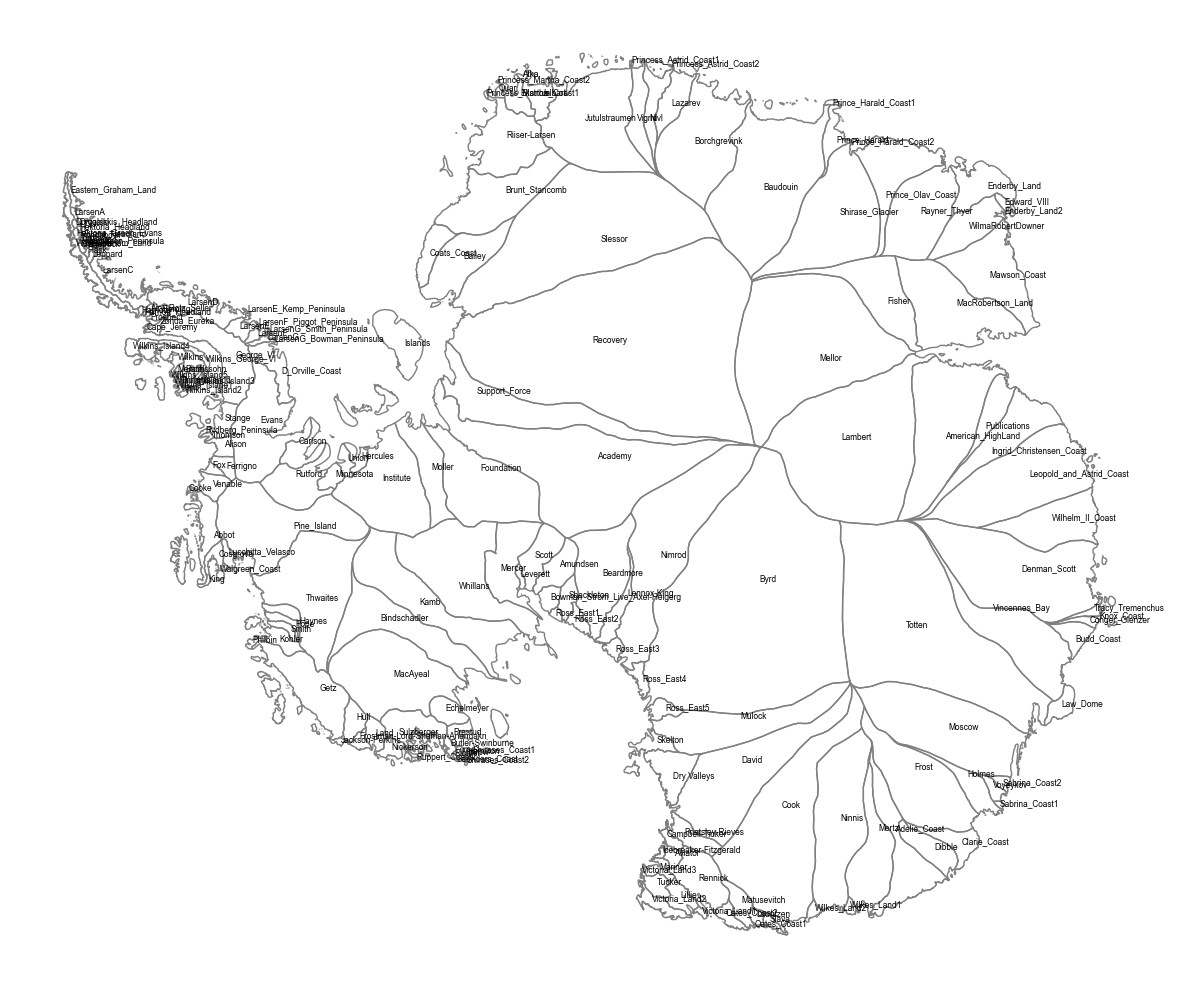

In [4]:
# To look at where all of those names plot on the map

# Plot all basin polygons
fig, ax = plt.subplots(figsize=(12, 12))
gdf.plot(ax=ax, facecolor='none', edgecolor='gray')

# Label each basin by its unique name
for _, row in gdf.iterrows():
    point = row.geometry.representative_point()  # safer than centroid for labels
    ax.text(point.x, point.y, str(row['NAME']), fontsize=6)

plt.axis('off')
plt.tight_layout()
plt.show()

# Uncomment this if you want to save this and zoom in to some of the weirder little nooks n crannies
#fig.savefig("antarctica_named_basins.png", dpi=300)

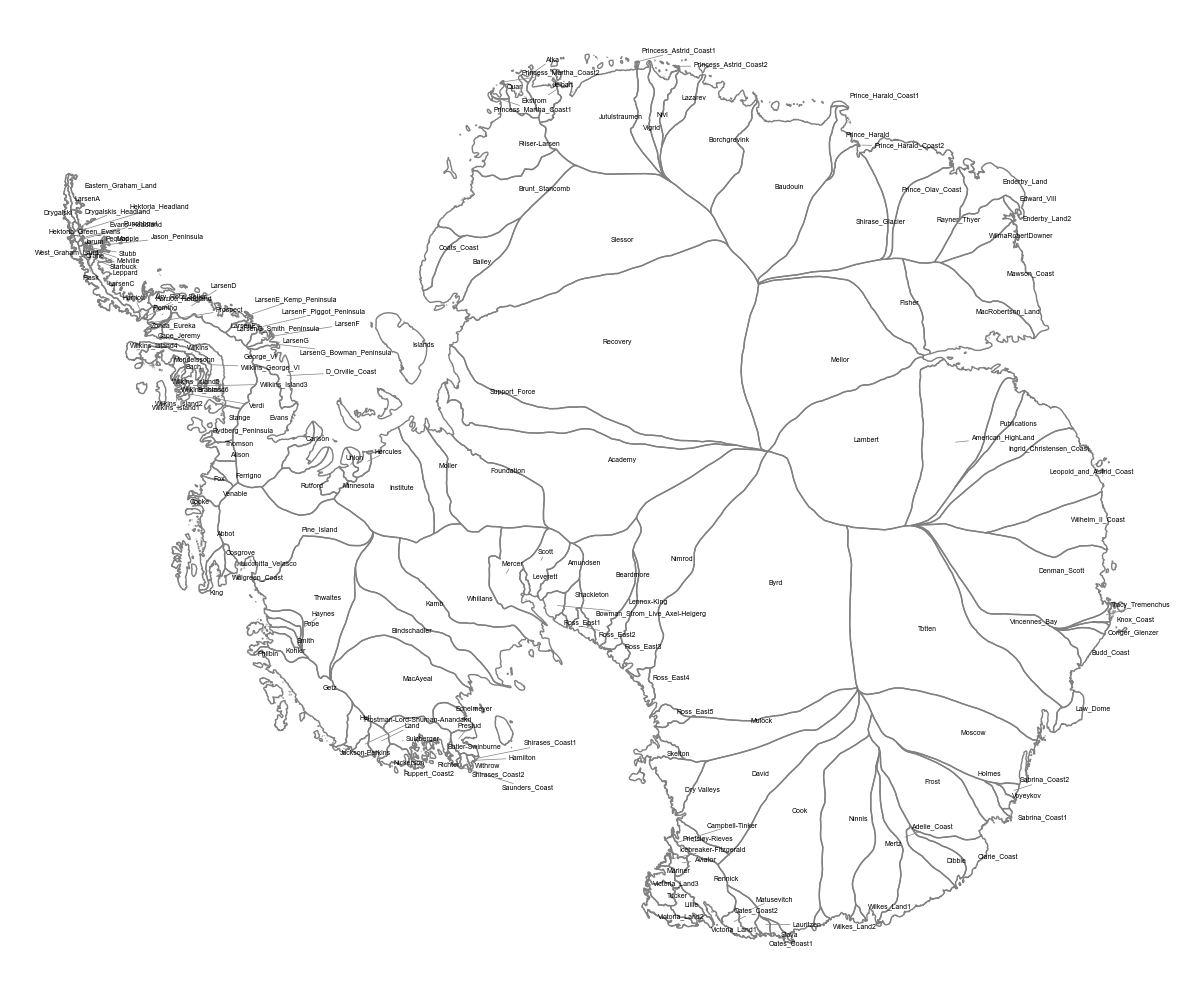

In [5]:
# Now you can look at this in a less shitty way
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(12, 12))
gdf.plot(ax=ax, facecolor='none', edgecolor='gray')

texts = []
for _, row in gdf.iterrows():
    point = row.geometry.representative_point()
    texts.append(ax.text(point.x, point.y, str(row['NAME']), fontsize=5))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.axis('off')
plt.tight_layout()
plt.show()

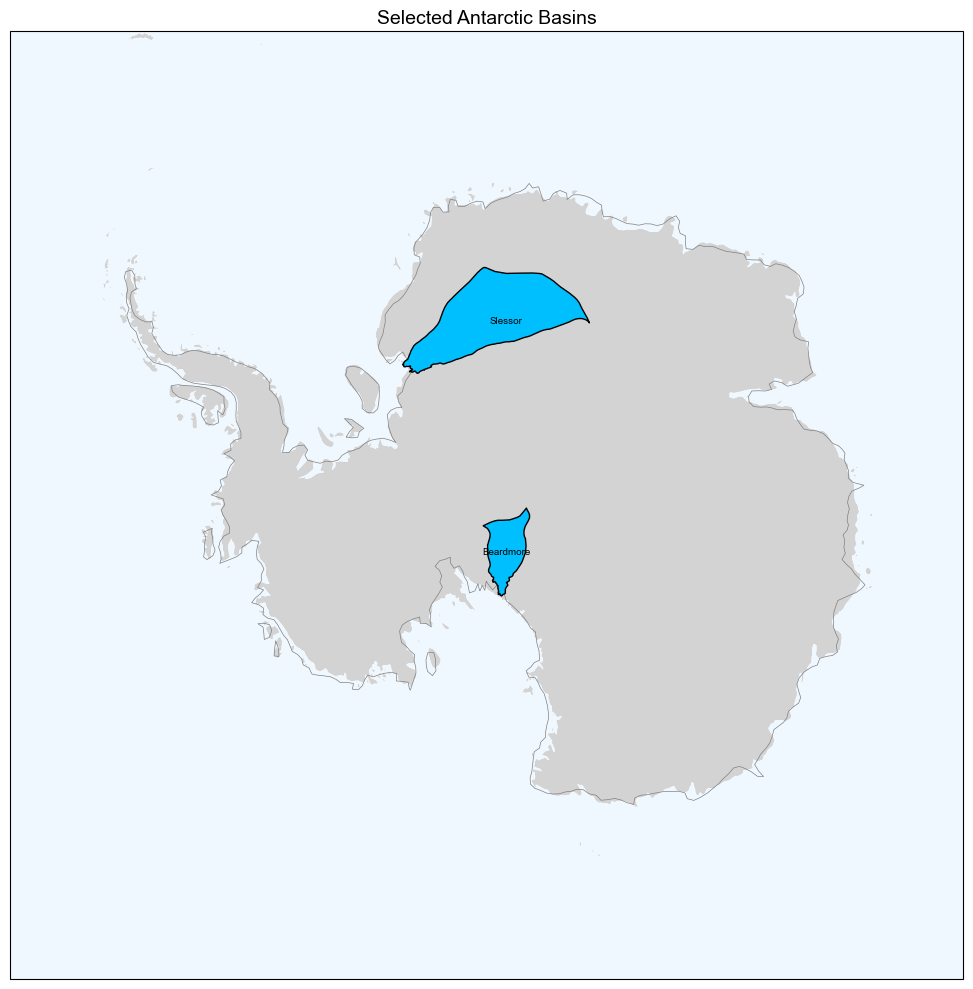

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Read and *label* the shapefile as EPSG:3031
gdf = gpd.read_file("Basins_Antarctica_v02.shp")
gdf = gdf.set_crs(epsg=3031, inplace=False)   # now gdf.crs == EPSG:3031

# 2) Subset
my_basins = ['Beardmore', 'Slessor']
selected = gdf[gdf['NAME'].isin(my_basins)]

# 3) Plot on South Polar Stereo — data are already in that CRS
proj = ccrs.SouthPolarStereo()

fig, ax = plt.subplots(figsize=(10, 10),
                       subplot_kw={'projection': proj})

# basemap
ax.add_feature(cfeature.LAND,   facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.OCEAN,  facecolor='aliceblue', zorder=0)
ax.coastlines(resolution='110m', linewidth=0.5, color='gray')

# add basin polygons
ax.add_geometries(
    selected.geometry,
    crs=proj,
    facecolor='deepskyblue',
    edgecolor='black',
    linewidth=1,
    zorder=3
)

# labels
for _, row in selected.iterrows():
    pt = row.geometry.representative_point()
    ax.text(
        pt.x, pt.y, row['NAME'],
        transform=proj,
        fontsize=7,
        ha='center', va='center'
    )

# extent and title
ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
plt.title("Selected Antarctic Basins", fontsize=14)
plt.tight_layout()
plt.show()

### Assign Sites to a Basin

In [7]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# ── A) Load & prepare the basins GeoDataFrame ──
basins = gpd.read_file("Basins_Antarctica_v02.shp")
basins = basins.set_crs(
    "+proj=stere +lat_0=-90 +lat_ts=-71 +lon_0=0 "
    "+datum=WGS84 +units=m +no_defs",
    allow_override=True
)[['NAME','geometry']]

# ── B) Load your sites & turn into a GeoDataFrame ──
sites = pd.read_csv("paleoexfiltrationperm13mean.csv")[['Site','Latitude','Longitude']].drop_duplicates()
site_gdf = gpd.GeoDataFrame(
    sites,
    geometry=[Point(xy) for xy in zip(sites.Longitude, sites.Latitude)],
    crs="EPSG:4326"
).to_crs(basins.crs)

# ── C) First, try a strict “within” join ──
site_basins = gpd.sjoin(
    site_gdf, basins,
    how='left',
    predicate='within'
).drop(columns=['index_right'])

# ── D) Snap any NaNs to the nearest basin ──
nan_mask = site_basins['NAME'].isna()
if nan_mask.any():
    missing = site_basins.loc[nan_mask, ['geometry']]
    nearest = gpd.sjoin_nearest(
        missing,
        basins,
        how='left',
        distance_col='dist_m'
    )
    # fill in the NAME & record distance
    site_basins.loc[nan_mask, 'NAME'] = nearest['NAME'].values
    site_basins.loc[nan_mask, 'dist_to_basin_m'] = nearest['dist_m'].values

# ── E) Print out which basin each site ended up in ──
for _, row in site_basins.sort_values('Site').iterrows():
    suffix = ""
    if 'dist_to_basin_m' in row and not pd.isna(row['dist_to_basin_m']):
        suffix = f"  (snapped: {row['dist_to_basin_m']:.1f} m)"
    print(f"Site {int(row['Site']):3d} → Basin: {row['NAME']}{suffix}")

Site   4 → Basin: Prince_Olav_Coast  (snapped: 0.9 m)
Site   7 → Basin: Prince_Olav_Coast  (snapped: 3563.7 m)
Site  11 → Basin: Prince_Olav_Coast  (snapped: 3042.6 m)
Site  15 → Basin: Ingrid_Christensen_Coast  (snapped: 6220.5 m)
Site  17 → Basin: Ingrid_Christensen_Coast  (snapped: 51.8 m)
Site  21 → Basin: Jutulstraumen
Site  22 → Basin: Jutulstraumen
Site  24 → Basin: Mawson_Coast
Site  27 → Basin: Campbell-Tinker
Site  28 → Basin: David
Site  30 → Basin: David
Site  33 → Basin: Byrd
Site  34 → Basin: Byrd
Site  37 → Basin: Skelton
Site  40 → Basin: Fisher
Site  42 → Basin: Islands
Site  45 → Basin: Aviator
Site  46 → Basin: Ross_East5
Site  47 → Basin: Ross_East5
Site  49 → Basin: Dry Valleys
Site  50 → Basin: Dry Valleys
Site  52 → Basin: Dry Valleys
Site  54 → Basin: Dry Valleys
Site  56 → Basin: Lennox-King
Site  57 → Basin: Lennox-King
Site  59 → Basin: Shackleton
Site  60 → Basin: Scott
Site  61 → Basin: Scott
Site  62 → Basin: Mercer
Site  64 → Basin: Mercer
Site  67 → Basi

In [8]:
# Extract unique basin names and wrap each in single quotes:
unique_basins = site_basins['NAME'].dropna().unique()
basin_list = ", ".join(f"'{name}'" for name in unique_basins)

print(basin_list)

'Prince_Olav_Coast', 'Ingrid_Christensen_Coast', 'Jutulstraumen', 'Mawson_Coast', 'Campbell-Tinker', 'David', 'Byrd', 'Skelton', 'Fisher', 'Islands', 'Aviator', 'Ross_East5', 'Dry Valleys', 'Lennox-King', 'Shackleton', 'Scott', 'Mercer', 'Tucker', 'Jason_Peninsula', 'Eastern_Graham_Land', 'Drygalski', 'Academy', 'Rutford', 'Hercules', 'Foundation', 'Institute', 'Sulzberger', 'Pope', 'Walgreen_Coast', 'Lucchitta_Velasco', 'Pine_Island'


In [2]:
!pip install matplotlib-scalebar

### Sites on the Landsat Basemap 

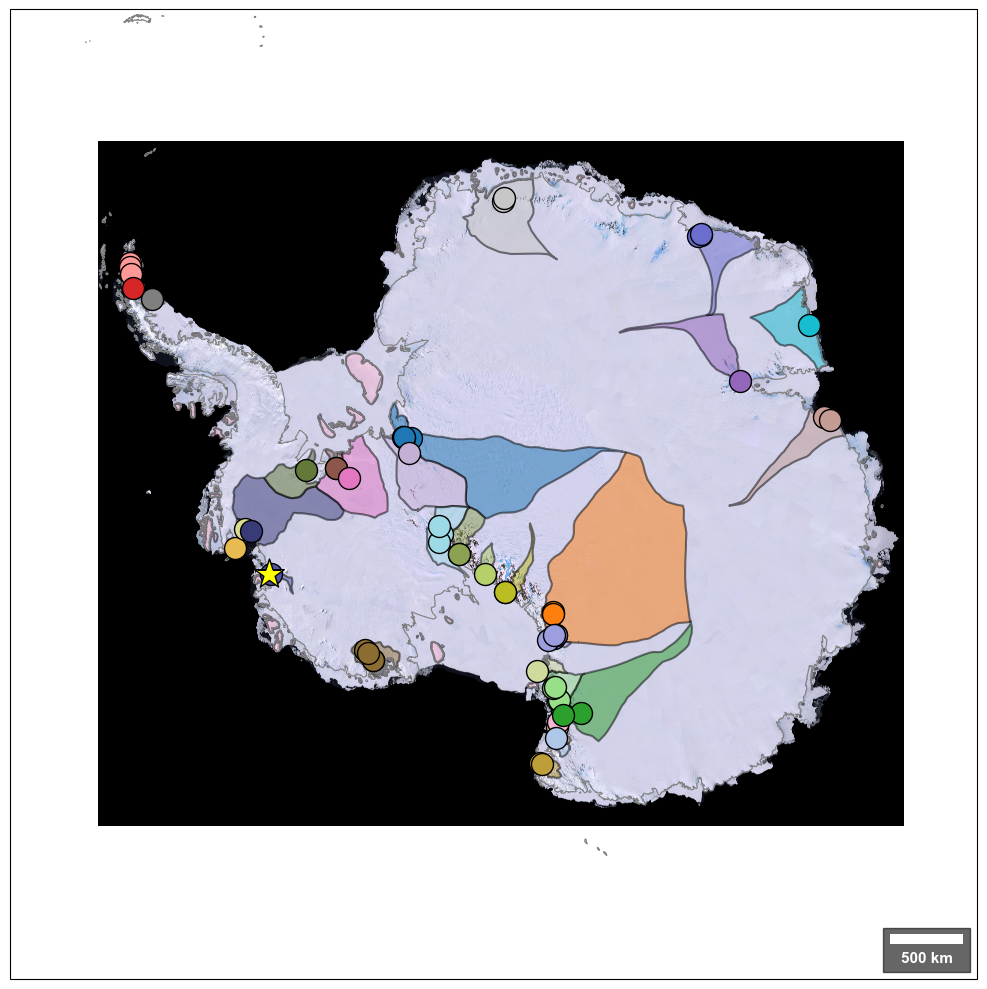

In [30]:
import sys
subprocess.run([sys.executable, "-m", "pip", "install", "matplotlib-scalebar"], check=True)

from matplotlib_scalebar.scalebar import ScaleBar

import os
import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap
from shapely.ops import nearest_points
from polartoolkit import fetch
 
# pip install matplotlib-scalebar  (if not installed)
from matplotlib_scalebar.scalebar import ScaleBar
 
# ── 0) Prevent GeoPandas auto‐CRS lookup if a .prj exists ──
prj = "Basins_Antarctica_v02.prj"
if os.path.exists(prj):
    os.rename(prj, prj + ".bak")
 
# ── 1) Load & label Basins shapefile as Antarctic Polar Stereographic ──
basins = gpd.read_file("Basins_Antarctica_v02.shp")
basins = basins.set_crs(
    "+proj=stere +lat_0=-90 +lat_ts=-71 +lon_0=0 "
    "+datum=WGS84 +units=m +no_defs",
    allow_override=True
)
 
# ── 2) Select desired basins ──
my_basins = [
    'Prince_Olav_Coast', 'Ingrid_Christensen_Coast', 'Jutulstraumen',
    'Mawson_Coast', 'Campbell-Tinker', 'David', 'Byrd', 'Skelton',
    'Fisher', 'Islands', 'Aviator', 'Ross_East5', 'Dry Valleys',
    'Lennox-King', 'Shackleton', 'Scott', 'Mercer', 'Tucker',
    'Jason_Peninsula', 'Eastern_Graham_Land', 'Drygalski', 'Academy',
    'Rutford', 'Hercules', 'Foundation', 'Institute', 'Sulzberger',
    'Pope', 'Walgreen_Coast', 'Lucchitta_Velasco', 'Pine_Island'
]
selected = basins[basins['NAME'].isin(my_basins)].copy()
 
# ── 3) Load site data ──
exfil_df = pd.read_csv("paleoexfiltrationperm13mean.csv")
unique_sites = exfil_df[['Longitude', 'Latitude']].drop_duplicates()
 
# ── 4) Fetch LIMA imagery ──
lima_path = fetch.imagery()
with rasterio.open(lima_path) as src:
    bands = src.read()
    rgb = np.moveaxis(bands, 0, 2)
    left, bottom, right, top = src.bounds
 
# ── 5) Build map ──
proj = ccrs.SouthPolarStereo(
    central_longitude=0,
    true_scale_latitude=-71
)
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": proj})
 
# a) LIMA basemap
ax.imshow(
    rgb,
    origin='upper',
    extent=(left, right, bottom, top),
    transform=proj,
    zorder=0
)
 
# ── b) Assign one unique color per basin ──
unique_basins = sorted(selected['NAME'].unique())
n = len(unique_basins)
 
palette = (
    list(plt.cm.tab20.colors) +
    list(plt.cm.tab20b.colors) +
    list(plt.cm.tab20c.colors)
)
 
if n > len(palette):
    raise ValueError(f"Need {n} colors, only have {len(palette)}")
 
palette = palette[:n]
color_map = dict(zip(unique_basins, palette))
selected['plot_color'] = selected['NAME'].map(color_map)
 
# Plot basins
for basin_name, basin_df in selected.groupby('NAME'):
    ax.add_geometries(
        basin_df.geometry,
        crs=proj,
        facecolor=color_map[basin_name],
        alpha=0.5,
        edgecolor='black',
        linewidth=1.5,
        zorder=1
    )
 
# ── c) Site points: assign basin color, including nearest basin if outside ──
site_gdf = gpd.GeoDataFrame(
    unique_sites,
    geometry=gpd.points_from_xy(
        unique_sites['Longitude'],
        unique_sites['Latitude']
    ),
    crs="EPSG:4326"
).to_crs(selected.crs)
 
# Spatial join: intersecting basins
site_gdf = gpd.sjoin(
    site_gdf,
    selected[['NAME', 'geometry']],
    how="left",
    predicate='intersects'
)
 
# Assign nearest basin for sites not matched
missing = site_gdf[site_gdf['NAME'].isna()]
if not missing.empty:
    for idx, row in missing.iterrows():
        distances = selected.geometry.distance(row.geometry)
        nearest_basin_idx = distances.idxmin()
        nearest_basin_name = selected.loc[nearest_basin_idx, 'NAME']
        site_gdf.at[idx, 'NAME'] = nearest_basin_name
 
# Assign colors
site_gdf['color'] = site_gdf['NAME'].map(color_map)
 
# Plot sites
for _, row in site_gdf.iterrows():
    ax.scatter(
        row.geometry.x,
        row.geometry.y,
        color=row.color,
        s=250,
        marker='o',
        edgecolor='black',
        linewidth=1,
        transform=proj,
        zorder=2
    )
 
# ── d) Kay Peak Ridge star ──
kp_lon, kp_lat = -110.95, -75.2333333
ax.scatter(
    kp_lon,
    kp_lat,
    transform=ccrs.PlateCarree(),
    marker='*',
    s=500,
    facecolor='yellow',
    edgecolor='black',
    linewidth=1,
    zorder=3
)
 
# ── Map decorations ──
ax.coastlines(resolution='10m', linewidth=0.8, color='gray')
ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
 
# ── e) Scale bar ──
# Get axes width in data units (metres) to set a sensible fixed length
ax_width_m = ax.get_extent(crs=proj)[1] - ax.get_extent(crs=proj)[0]  # in metres

scalebar = ScaleBar(
    dx=1,                    # 1 data unit = 1 metre
    units='m',               # base unit
    dimension='si-length',   # auto-picks km prefix
    fixed_value=500,         # fix the bar to exactly 500 km
    fixed_units='km',        # display in km
    location='lower right',
    pad=0.5,
    border_pad=0.5,
    sep=5,
    frameon=True,
    color='white',
    box_color='black',
    box_alpha=0.6,
    font_properties={'size': 11, 'weight': 'bold'},
    label_loc='top',
    scale_loc='bottom',
)
ax.add_artist(scalebar)
 
plt.tight_layout()
 
# ── Save & show ──
fig.savefig("antarcticbasinsites.pdf", dpi=700, bbox_inches="tight")
plt.show()

## Make key for map above 

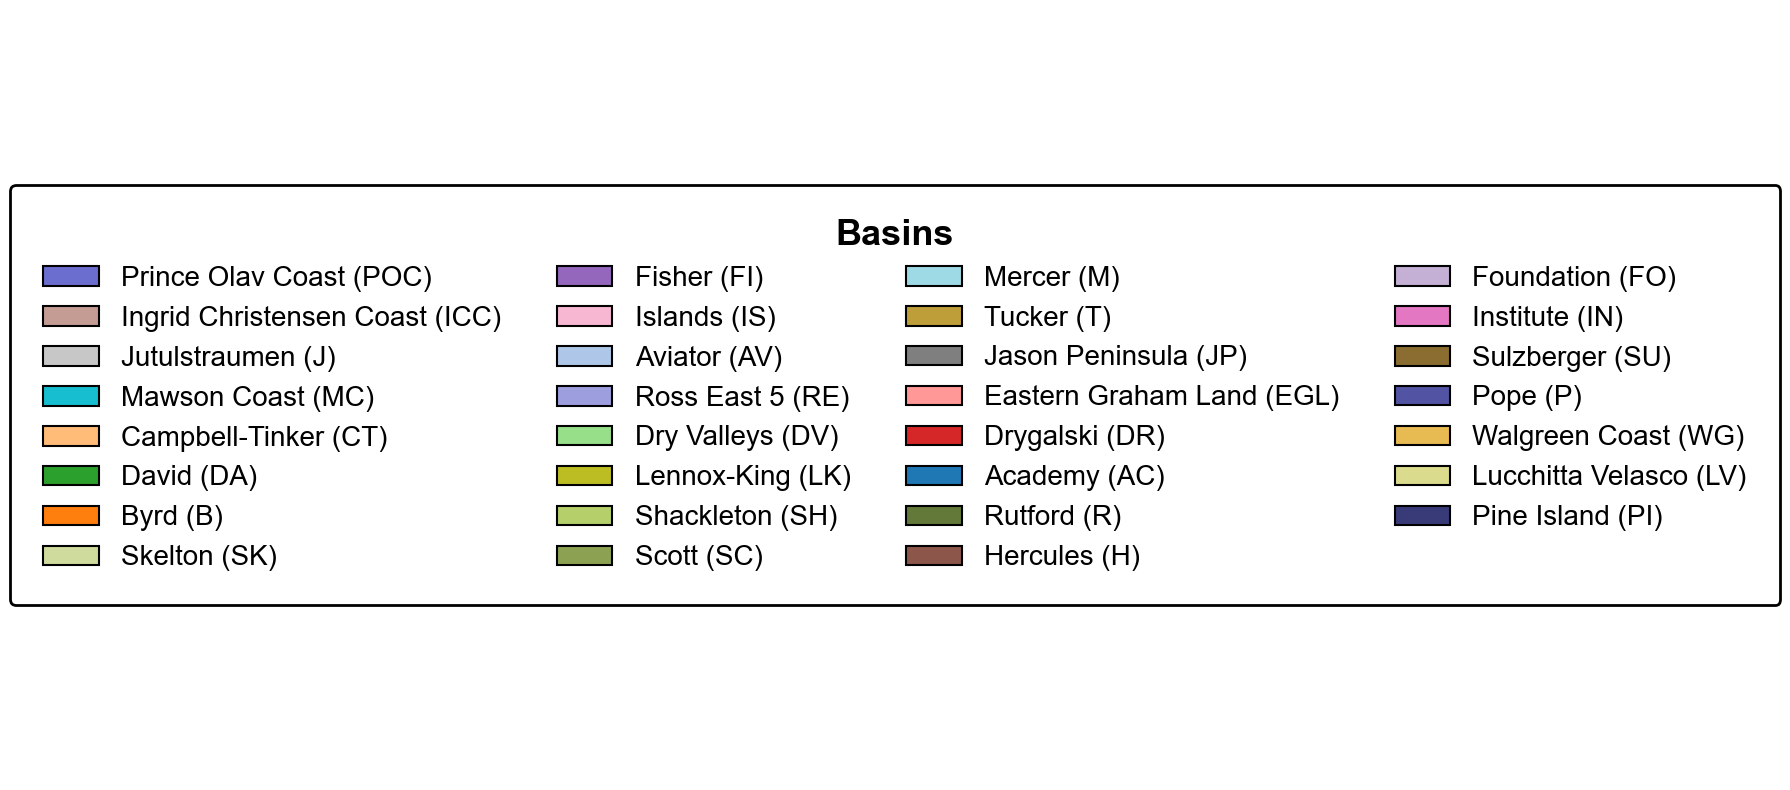

In [35]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import Patch

plt.rcParams['font.family'] = 'Arial'

display_order = [
    'Prince Olav Coast (POC)', 'Ingrid Christensen Coast (ICC)', 'Jutulstraumen (J)',
    'Mawson Coast (MC)', 'Campbell-Tinker (CT)', 'David (DA)', 'Byrd (B)', 'Skelton (SK)',
    'Fisher (FI)', 'Islands (IS)', 'Aviator (AV)', 'Ross East 5 (RE)', 'Dry Valleys (DV)',
    'Lennox-King (LK)', 'Shackleton (SH)', 'Scott (SC)', 'Mercer (M)', 'Tucker (T)',
    'Jason Peninsula (JP)', 'Eastern Graham Land (EGL)', 'Drygalski (DR)', 'Academy (AC)',
    'Rutford (R)', 'Hercules (H)', 'Foundation (FO)', 'Institute (IN)', 'Sulzberger (SU)',
    'Pope (P)', 'Walgreen Coast (WG)', 'Lucchitta Velasco (LV)', 'Pine Island (PI)'
]

name_corrections = {
    'Prince Olav Coast (POC)': 'Prince_Olav_Coast',
    'Ingrid Christensen Coast (ICC)': 'Ingrid_Christensen_Coast',
    'Jutulstraumen (J)': 'Jutulstraumen',
    'Mawson Coast (MC)': 'Mawson_Coast',
    'Campbell-Tinker (CT)': 'Campbell-Tinker',
    'David (DA)': 'David',
    'Byrd (B)': 'Byrd',
    'Skelton (SK)': 'Skelton',
    'Fisher (FI)': 'Fisher',
    'Islands (IS)': 'Islands',
    'Aviator (AV)': 'Aviator',
    'Ross East 5 (RE)': 'Ross_East5',
    'Dry Valleys (DV)': 'Dry Valleys',
    'Lennox-King (LK)': 'Lennox-King',
    'Shackleton (SH)': 'Shackleton',
    'Scott (SC)': 'Scott',
    'Mercer (M)': 'Mercer',
    'Tucker (T)': 'Tucker',
    'Jason Peninsula (JP)': 'Jason_Peninsula',
    'Eastern Graham Land (EGL)': 'Eastern_Graham_Land',
    'Drygalski (DR)': 'Drygalski',
    'Academy (AC)': 'Academy',
    'Rutford (R)': 'Rutford',
    'Hercules (H)': 'Hercules',
    'Foundation (FO)': 'Foundation',
    'Institute (IN)': 'Institute',
    'Sulzberger (SU)': 'Sulzberger',
    'Pope (P)': 'Pope',
    'Walgreen Coast (WG)': 'Walgreen_Coast',
    'Lucchitta Velasco (LV)': 'Lucchitta_Velasco',
    'Pine Island (PI)': 'Pine_Island'
}

legend_handles = []
for display_name in display_order:
    basin_key = name_corrections[display_name]
    color = color_map.get(basin_key, 'lightgrey')
    legend_handles.append(
        Patch(facecolor=color, edgecolor='black', linewidth=1.5, label=display_name)
    )

# Use explicit FontProperties to guarantee point size is respected
font = fm.FontProperties(family='Arial', size=20)
title_font = fm.FontProperties(family='Arial', size=26, weight='bold')

fig, ax = plt.subplots(figsize=(20, 10))
ax.axis('off')

legend = ax.legend(
    handles=legend_handles,
    title='Basins',
    loc='center',
    prop=font,                  # controls entry font size explicitly
    title_fontproperties=title_font,
    frameon=True,
    framealpha=1.0,
    handlelength=2.0,
    borderpad=1.2,
    ncol=4
)

legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(2.0)

# Do NOT use bbox_inches='tight' — it shrinks the canvas and makes text appear small
fig.savefig("basinlegend.png", dpi=150, transparent=True)
plt.show()

In [54]:
# Function to convert RGB tuple to hex
def rgb_to_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(
        int(rgb[0]*255),
        int(rgb[1]*255),
        int(rgb[2]*255)
    )

print("Basin Color Key (HEX):\n")
for display_name in display_order:
    basin_key = lookup_key(display_name)
    rgb_color = color_map.get(basin_key, (0.8, 0.8, 0.8))  # fallback light gray
    hex_color = rgb_to_hex(rgb_color)
    print(f"{display_name}: {hex_color}")


Basin Color Key (HEX):

Prince Olav Coast (POC): #6b6ecf
Ingrid Christensen Coast (ICC): #c49c94
Jutulstraumen (J): #c7c7c7
Mawson Coast (MC): #17becf
Campbell-Tinker (CT): #ffbb78
David (DA): #2ca02c
Byrd (B): #ff7f0e
Skelton (SK): #cedb9c
Fisher (FI): #9467bd
Islands (IS): #f7b6d2
Aviator (AV): #aec7e8
Ross East 5 (RE): #9c9ede
Dry Valleys (DV): #98df8a
Lennox-King (LK): #bcbd22
Shackleton (SH): #b5cf6b
Scott (SC): #8ca252
Mercer (M): #9edae5
Tucker (T): #bd9e39
Jason Peninsula (JP): #7f7f7f
Eastern Graham Land (EGL): #ff9896
Drygalski (DR): #d62728
Academy (AC): #1f77b4
Rutford (R): #637939
Hercules (H): #8c564b
Foundation (FO): #c5b0d5
Institute (IN): #e377c2
Sulzberger (SU): #8c6d31
Pope (P): #5254a3
Walgreen Coast (WG): #e7ba52
Lucchitta Velasco (LV): #dbdb8d
Pine Island (PI): #393b79
